In [ ]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torchvision.utils import save_image, make_grid
from torch.utils.data import DataLoader




In [ ]:

dataset_choice = "mnist"   # 'mnist'
# dataset_choice = "fashion"
epochs = 5
batch_size = 64
noise_dim = 100
learning_rate = 0.0002
save_interval = 5

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

os.makedirs("generated_samples", exist_ok=True)
os.makedirs("final_generated_images", exist_ok=True)

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

if dataset_choice == "mnist":
    dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
elif dataset_choice == "fashion":
    dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
else:
    raise ValueError("Invalid dataset choice")

loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

img_shape = (1, 28, 28)


class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(noise_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, 28 * 28),
            nn.Tanh()
        )

    def forward(self, z):
        img = self.model(z)
        return img.view(z.size(0), *img_shape)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(28 * 28, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        return self.model(img.view(img.size(0), -1))

G = Generator().to(device)
D = Discriminator().to(device)

criterion = nn.BCELoss()
optimizer_G = optim.Adam(G.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = optim.Adam(D.parameters(), lr=learning_rate, betas=(0.5, 0.999))



100%|██████████| 9.91M/9.91M [00:00<00:00, 59.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.73MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 14.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.43MB/s]


In [ ]:
g_grad_history = []
d_grad_history = []


In [ ]:
def grad_norm(model):
    total_norm = 0.0
    for p in model.parameters():
        if p.grad is not None:
            param_norm = p.grad.data.norm(2)
            total_norm += param_norm.item() ** 2
    return total_norm ** 0.5


In [ ]:
for epoch in range(1, epochs + 1):
    d_loss_epoch = 0
    g_loss_epoch = 0

    d_grad_epoch = 0.0
    g_grad_epoch = 0.0
    grad_steps = 0

    correct = 0
    total = 0

    for imgs, _ in loader:
        imgs = imgs.to(device)
        real_labels = torch.ones(imgs.size(0), 1).to(device)
        fake_labels = torch.zeros(imgs.size(0), 1).to(device)

        # ---------- Train Discriminator ----------
        optimizer_D.zero_grad()

        outputs_real = D(imgs)
        loss_real = criterion(outputs_real, real_labels)

        z = torch.randn(imgs.size(0), noise_dim).to(device)
        fake_imgs = G(z)
        outputs_fake = D(fake_imgs.detach())
        loss_fake = criterion(outputs_fake, fake_labels)

        d_loss = loss_real + loss_fake
        d_loss.backward()

        d_grad_epoch += grad_norm(D)

        optimizer_D.step()

        # Accuracy
        correct += (outputs_real > 0.5).sum().item()
        correct += (outputs_fake < 0.5).sum().item()
        total += 2 * imgs.size(0)

        # ---------- Train Generator ----------
        optimizer_G.zero_grad()

        outputs = D(fake_imgs)
        g_loss = criterion(outputs, real_labels)
        g_loss.backward()

        g_grad_epoch += grad_norm(G)

        optimizer_G.step()

        grad_steps += 1

        d_loss_epoch += d_loss.item()
        g_loss_epoch += g_loss.item()

    # Epoch averages
    d_loss_epoch /= len(loader)
    g_loss_epoch /= len(loader)

    g_grad_history.append(g_grad_epoch / grad_steps)
    d_grad_history.append(d_grad_epoch / grad_steps)

    d_acc = 100 * correct / total

    print(
        f"Epoch {epoch}/{epochs} | "
        f"D_loss: {d_loss_epoch:.4f} | "
        f"D_acc: {d_acc:.2f}% | "
        f"G_loss: {g_loss_epoch:.4f}"
    )


Epoch 1/5 | D_loss: 0.9498 | D_acc: 74.40% | G_loss: 1.8128
Epoch 2/5 | D_loss: 0.6803 | D_acc: 88.38% | G_loss: 3.0054
Epoch 3/5 | D_loss: 0.5677 | D_acc: 90.77% | G_loss: 3.5784
Epoch 4/5 | D_loss: 0.6075 | D_acc: 90.47% | G_loss: 3.5153
Epoch 5/5 | D_loss: 0.5410 | D_acc: 91.57% | G_loss: 3.6860


In [ ]:
import matplotlib.pyplot as plt

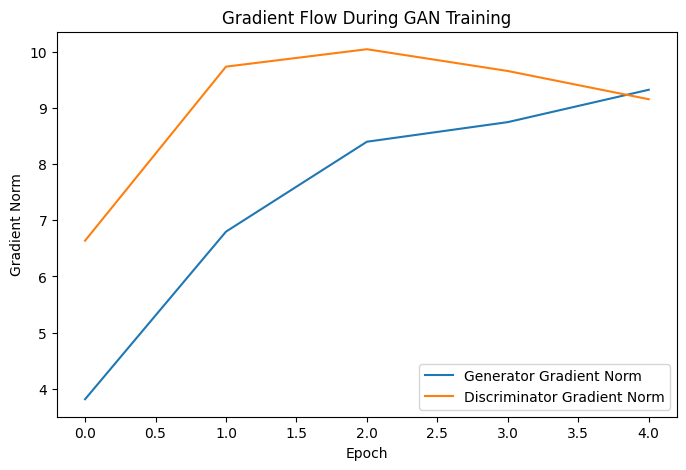

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(g_grad_history, label="Generator Gradient Norm")
plt.plot(d_grad_history, label="Discriminator Gradient Norm")
plt.xlabel("Epoch")
plt.ylabel("Gradient Norm")
plt.legend()
plt.title("Gradient Flow During GAN Training")
plt.show()


In [ ]:
final_images = []
with torch.no_grad():
    for i in range(100):
        z = torch.randn(1, noise_dim).to(device)
        img = G(z)
        img = (img + 1) / 2
        save_image(img, f"final_generated_images/img_{i:03d}.png")
        final_images.append(img)

In [ ]:
classifier = models.resnet18(pretrained=True)
classifier.fc = nn.Linear(classifier.fc.in_features, 10)
classifier.eval()

label_counts = torch.zeros(10)

with torch.no_grad():
    for img in final_images:
        img_resized = nn.functional.interpolate(img, size=(224, 224))
        img_resized = img_resized.repeat(1, 3, 1, 1)
        output = classifier(img_resized)
        label = torch.argmax(output, dim=1)
        label_counts[label] += 1

print("\nLabel Distribution of Generated Images:")
for i in range(10):
    print(f"Label {i}: {int(label_counts[i])}")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 75.4MB/s]



Label Distribution of Generated Images:
Label 0: 0
Label 1: 0
Label 2: 100
Label 3: 0
Label 4: 0
Label 5: 0
Label 6: 0
Label 7: 0
Label 8: 0
Label 9: 0


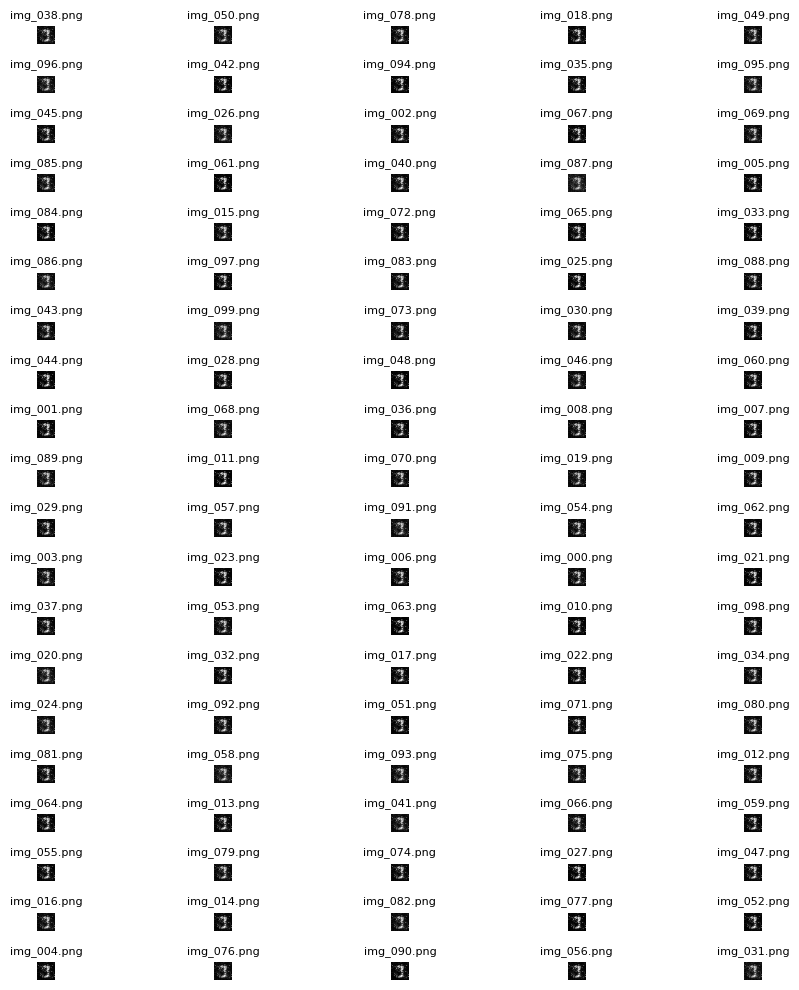

In [ ]:
import os
import matplotlib.pyplot as plt
from PIL import Image

folder = "final_generated_images"
files = [f for f in os.listdir(folder) if f.endswith(".png")]

cols = 5
rows = (len(files) + cols - 1) // cols

plt.figure(figsize=(10, 10))

for i, file in enumerate(files):
    img = Image.open(os.path.join(folder, file))
    plt.subplot(rows, cols, i + 1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(file, fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# GRADIENT NORM